In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [2]:
gold_data = pd.read_csv('gld_price_data.csv')
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [3]:
gold_data.shape

(2290, 6)

In [4]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [5]:
gold_data.duplicated().sum()

0

In [6]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [7]:
corr = gold_data.corr()
corr

C:\Users\HP\AppData\Local\Temp\ipykernel_20172\2791445336.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = gold_data.corr()


,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


In [8]:
print(corr['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<Axes: >

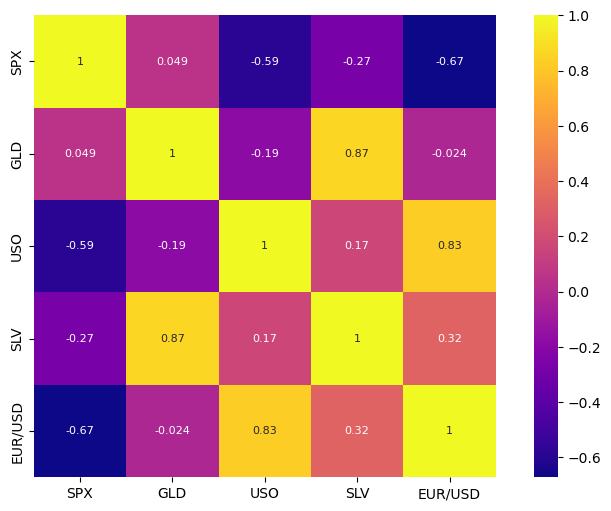

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, annot_kws={'size':8}, cmap='plasma', cbar=True, square=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_20172\287148093.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='green')


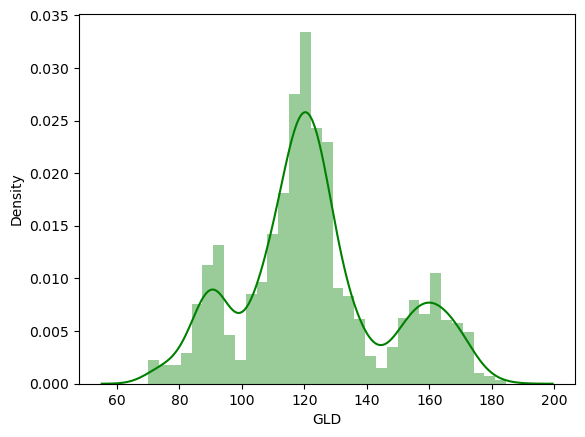

In [10]:
sns.distplot(gold_data['GLD'], color='green')
plt.show()

# Splitting Features and Target

In [11]:
X = gold_data.drop(['Date', 'GLD'], axis=1)
y = gold_data["GLD"]

In [12]:
X.head(3)

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492


In [13]:
y.head(3)

0    84.860001
1    85.570000
2    85.129997
Name: GLD, dtype: float64

In [14]:
X.shape

(2290, 4)

In [15]:
y.shape

(2290,)

# Train, Test and Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)

In [17]:
X_train.shape

(1717, 4)

In [18]:
X_test.shape

(573, 4)

In [19]:
y_train.shape

(1717,)

In [20]:
y_test.shape

(573,)

In [21]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
r2_score(y_pred, y_test)

0.9856471617235298

In [22]:
print(y_pred)

[121.13680054 116.23249987 157.58800105 167.09299835 149.01439842
 124.9571011  128.82150169  88.94479951  91.07509747 132.07860299
 117.1295013  172.225501   146.20649891 120.9134023  122.24569977
 122.10380091  90.77199887  91.06050028  93.78520017 168.36449911
 112.97900046 119.51760022 110.12839962 141.64150042 128.0493992
  88.77529899 146.53179996 127.71919907 124.51240143  81.61160081
  84.69479922 134.29030203 146.15669989 152.95469931  83.5336996
 132.93810152 155.10560258 109.01079995 127.44719888 122.19398928
 164.86620248 113.51779946 111.01169985 132.93920169 112.34150098
  76.5846012  152.37539953 113.6353993  118.1366015  117.57320074
 119.57000063 156.95100051  87.68319971 128.34799967 102.84719847
  90.77410017 156.41549978 114.83219946 118.33790069 122.39079886
 150.18099713 118.3714003  131.07500109 117.58099966 172.04930122
 155.15099799 151.96630241 103.34440103 161.33710028 136.41990074
 147.98859906  99.21049942 121.09640055 153.69100169 132.35500139
 121.5681994